# DriftGuard — Hybrid Rules and Model Engine

This notebook combines:

- The repository-disjoint primary learned classifier
- Weighted predictions from all three trained model families
- Deterministic security rules
- Safety-oriented model-consensus escalation
- Explicit uncertainty and manual-review routing

The final hybrid decision follows this order:

1. Generate the weighted model ensemble.
2. Apply agreement-based safety escalation.
3. Apply deterministic security-rule overrides.
4. Mark uncertain or conflicting cases for manual review.
5. Preserve explanations for every override and escalation.

Important limitations:

- Repository-disjoint validation labels remain weak labels.
- Many validation labels were originally generated using security rules.
- Rule-based validation results therefore measure rule consistency and must not
  be treated as independent human-verified performance.
- The sealed final test remains untouched.

In [1]:
import json
import math
import re
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
)


print("=" * 72)
print("DRIFTGUARD — HYBRID RULES AND MODEL ENGINE")
print("=" * 72)

current_directory = Path.cwd().resolve()

if current_directory.name.lower() == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

REPOSITORY_EVALUATION_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "repository_disjoint_evaluation"
)

VALIDATION_PREDICTIONS_PATH = (
    REPOSITORY_EVALUATION_DIR
    / "predictions"
    / "repository_validation_predictions.csv.gz"
)

PRIMARY_SELECTION_MANIFEST_PATH = (
    REPOSITORY_EVALUATION_DIR
    / "manifests"
    / "primary_model_selection_manifest.json"
)

SEALED_TEST_MANIFEST_PATH = (
    REPOSITORY_EVALUATION_DIR
    / "manifests"
    / "sealed_final_test_manifest.json"
)

OUTPUTS_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "hybrid_engine"
)

TABLES_DIR = OUTPUTS_DIR / "tables"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"
FIGURES_DIR = OUTPUTS_DIR / "figures"
REVIEW_DIR = OUTPUTS_DIR / "manual_review"
MANIFESTS_DIR = OUTPUTS_DIR / "manifests"

CONFIGS_DIR = PROJECT_ROOT / "configs"

for directory in [
    OUTPUTS_DIR,
    TABLES_DIR,
    PREDICTIONS_DIR,
    FIGURES_DIR,
    REVIEW_DIR,
    MANIFESTS_DIR,
    CONFIGS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

warnings.filterwarnings("default")

print("Project root       :", PROJECT_ROOT)
print("Validation input   :", VALIDATION_PREDICTIONS_PATH)
print("Output directory   :", OUTPUTS_DIR)

DRIFTGUARD — HYBRID RULES AND MODEL ENGINE
Project root       : C:\Users\Lenovo\Desktop\DriftGuard
Validation input   : C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation\predictions\repository_validation_predictions.csv.gz
Output directory   : C:\Users\Lenovo\Desktop\DriftGuard\outputs\hybrid_engine


In [2]:
HYBRID_ENGINE_SETTINGS = {
    "class_order": [
        "benign",
        "low",
        "medium",
        "high",
        "critical",
    ],

    "risk_rank": {
        "benign": 0,
        "low": 1,
        "medium": 2,
        "high": 3,
        "critical": 4,
    },

    "model_weights": {
        "structured": 0.40,
        "transformer": 0.35,
        "text_baseline": 0.25,
    },

    "two_model_high_critical_vote_rank": "high",

    "single_critical_support_probability": 0.45,

    "low_confidence_threshold": 0.50,

    "large_risk_spread_threshold": 2,

    "manual_review_queue_size": 750,

    "hybrid_score_boost": 0.35,

    "production_variant": "safety_hybrid",

    "selection_policy": (
        "Fixed safety architecture. It is not selected by maximizing "
        "weak-label validation performance."
    ),
}

CLASS_ORDER = HYBRID_ENGINE_SETTINGS[
    "class_order"
]

RISK_RANK = HYBRID_ENGINE_SETTINGS[
    "risk_rank"
]

RANK_TO_CLASS = {
    rank: class_name
    for class_name, rank
    in RISK_RANK.items()
}

MODEL_WEIGHTS = HYBRID_ENGINE_SETTINGS[
    "model_weights"
]

PRODUCTION_VARIANT = HYBRID_ENGINE_SETTINGS[
    "production_variant"
]

settings_path = (
    CONFIGS_DIR
    / "hybrid_engine_settings.json"
)

with settings_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        HYBRID_ENGINE_SETTINGS,
        file,
        indent=2,
    )

print(
    json.dumps(
        HYBRID_ENGINE_SETTINGS,
        indent=2,
    )
)

{
  "class_order": [
    "benign",
    "low",
    "medium",
    "high",
    "critical"
  ],
  "risk_rank": {
    "benign": 0,
    "low": 1,
    "medium": 2,
    "high": 3,
    "critical": 4
  },
  "model_weights": {
    "structured": 0.4,
    "transformer": 0.35,
    "text_baseline": 0.25
  },
  "two_model_high_critical_vote_rank": "high",
  "single_critical_support_probability": 0.45,
  "low_confidence_threshold": 0.5,
  "large_risk_spread_threshold": 2,
  "manual_review_queue_size": 750,
  "hybrid_score_boost": 0.35,
  "production_variant": "safety_hybrid",
  "selection_policy": "Fixed safety architecture. It is not selected by maximizing weak-label validation performance."
}


In [3]:
required_paths = {
    "validation predictions":
        VALIDATION_PREDICTIONS_PATH,

    "primary selection manifest":
        PRIMARY_SELECTION_MANIFEST_PATH,

    "sealed test manifest":
        SEALED_TEST_MANIFEST_PATH,
}

for artifact_name, artifact_path in required_paths.items():
    if not artifact_path.exists():
        raise FileNotFoundError(
            f"Missing {artifact_name}:\n{artifact_path}"
        )

validation_predictions = pd.read_csv(
    VALIDATION_PREDICTIONS_PATH,
    compression="gzip",
    low_memory=False,
)

with PRIMARY_SELECTION_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    primary_selection_manifest = json.load(file)

with SEALED_TEST_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    sealed_test_manifest = json.load(file)

PRIMARY_MODEL_NAME = (
    primary_selection_manifest[
        "selected_primary_model"
    ]
)

print(
    "Validation prediction records:",
    f"{len(validation_predictions):,}",
)

print(
    "Primary learned model:",
    PRIMARY_MODEL_NAME,
)

print(
    "Final test status:",
    sealed_test_manifest["status"],
)

print(
    "Final test SHA-256:",
    sealed_test_manifest["sha256"],
)

Validation prediction records: 7,628
Primary learned model: structured
Final test status: SEALED_NOT_LOADED
Final test SHA-256: cff0f85db740a195366fb81cbad26ba34859f40fe12bf8695b263d1cdedb9b67


In [4]:
RAW_RULE_COLUMNS = [
    "field_path",
    "old_value",
    "new_value",
    "configuration_type",
    "operation",
    "parser_mode",
    "file_path",
    "commit_message",
]

MODEL_NAMES = [
    "structured",
    "transformer",
    "text_baseline",
]

required_columns = (
    RAW_RULE_COLUMNS
    + [
        "repository",
        "commit_hash",
        "evaluation_label",
    ]
)

for model_name in MODEL_NAMES:
    required_columns.extend(
        [
            f"{model_name}_prediction",
            f"{model_name}_confidence",
        ]
    )

    required_columns.extend(
        [
            f"{model_name}_score_{class_name}"
            for class_name in CLASS_ORDER
        ]
    )

missing_columns = sorted(
    set(required_columns)
    - set(validation_predictions.columns)
)

if missing_columns:
    raise ValueError(
        "Missing required columns:\n"
        + "\n".join(missing_columns)
    )

if PRIMARY_MODEL_NAME not in MODEL_NAMES:
    raise ValueError(
        f"Unsupported primary model: {PRIMARY_MODEL_NAME}"
    )

print("Required-column validation: PASSED")

Required-column validation: PASSED


In [5]:
NULL_LIKE_VALUES = {
    "",
    "none",
    "null",
    "nil",
    "~",
    "<missing>",
    "<deleted>",
    "deleted",
    "unset",
    "undefined",
    "nan",
}

FALSE_LIKE_VALUES = {
    "0",
    "false",
    "no",
    "off",
    "disabled",
    "disable",
}

TRUE_LIKE_VALUES = {
    "1",
    "true",
    "yes",
    "on",
    "enabled",
    "enable",
}


def normalize_value(value):
    if value is None:
        return ""

    if isinstance(value, float) and np.isnan(value):
        return ""

    return re.sub(
        r"\s+",
        " ",
        str(value).strip().lower(),
    )


def contains_pattern(
    text,
    pattern,
):
    return bool(
        re.search(
            pattern,
            text,
            flags=re.IGNORECASE,
        )
    )


def value_is_missing(value):
    return normalize_value(value) in NULL_LIKE_VALUES


def change_is_removal(
    operation,
    new_value,
):
    normalized_operation = normalize_value(
        operation
    )

    return (
        normalized_operation
        in {
            "deleted",
            "delete",
            "removed",
            "remove",
        }
        or value_is_missing(
            new_value
        )
    )


print("Normalization helpers loaded.")

Normalization helpers loaded.


In [6]:
RULE_DEFINITIONS = {
    "TLS_DISABLED": {
        "severity": "critical",
        "confidence": 0.99,
        "description": (
            "TLS, SSL, HTTPS, or certificate protection "
            "appears to have been disabled or removed."
        ),
    },

    "AUTH_REMOVED": {
        "severity": "critical",
        "confidence": 0.99,
        "description": (
            "Authentication, authorization, credentials, "
            "or access-control configuration was removed."
        ),
    },

    "DEFAULT_CREDENTIALS": {
        "severity": "critical",
        "confidence": 0.99,
        "description": (
            "A credential field appears to use a common "
            "default or weak credential."
        ),
    },

    "OPEN_NETWORK_EXPOSURE": {
        "severity": "critical",
        "confidence": 0.98,
        "description": (
            "Network access appears open to every address "
            "or an unrestricted wildcard."
        ),
    },

    "PERMISSIVE_ACCESS_CONTROL": {
        "severity": "critical",
        "confidence": 0.98,
        "description": (
            "An access-control field appears to grant "
            "unrestricted or administrative access."
        ),
    },

    "INSECURE_PROTOCOL": {
        "severity": "high",
        "confidence": 0.96,
        "description": (
            "An insecure network protocol or obsolete "
            "transport-security version was introduced."
        ),
    },

    "PUBLIC_SERVICE_BINDING": {
        "severity": "high",
        "confidence": 0.94,
        "description": (
            "A service appears to have been bound publicly "
            "or exposed through a wildcard address."
        ),
    },

    "RESOURCE_LIMIT_REMOVED": {
        "severity": "medium",
        "confidence": 0.91,
        "description": (
            "A CPU, memory, storage, quota, or timeout "
            "limit appears to have been removed."
        ),
    },
}

for rule_id, rule_definition in RULE_DEFINITIONS.items():
    if rule_definition["severity"] not in CLASS_ORDER:
        raise ValueError(
            f"Invalid severity for {rule_id}"
        )

print(
    "Deterministic rules:",
    len(RULE_DEFINITIONS),
)

Deterministic rules: 8


In [7]:
DEFAULT_CREDENTIAL_VALUES = {
    "admin",
    "administrator",
    "root",
    "password",
    "passwd",
    "default",
    "changeme",
    "change_me",
    "changeit",
    "secret",
    "test",
    "demo",
    "guest",
    "1234",
    "12345",
    "123456",
    "admin123",
    "password123",
}

GLOBAL_NETWORK_VALUES = {
    "*",
    "0.0.0.0",
    "0.0.0.0/0",
    "::",
    "::/0",
    "any",
    "all",
    "world",
    "internet",
}

PERMISSIVE_ACCESS_VALUES = {
    "*",
    "all",
    "any",
    "everyone",
    "world",
    "anonymous",
    "public",
    "admin",
    "administrator",
    "cluster-admin",
    "root",
    "777",
    "allow all",
    "allow_all",
}

TLS_FIELD_PATTERN = (
    r"(?:tls|ssl|https|certificate|cert|"
    r"secure_transport|transport_security)"
)

AUTH_FIELD_PATTERN = (
    r"(?:auth|authentication|authorization|"
    r"password|passwd|secret|token|credential|"
    r"rbac|access_control|permission|policy)"
)

CREDENTIAL_FIELD_PATTERN = (
    r"(?:password|passwd|secret|token|credential|"
    r"api_key|apikey|private_key)"
)

NETWORK_FIELD_PATTERN = (
    r"(?:cidr|source_range|allowed_ip|ingress|egress|"
    r"firewall|security_group|network|subnet|address|"
    r"listen|bind|host|port)"
)

ACL_FIELD_PATTERN = (
    r"(?:acl|permission|rbac|role|policy|authorization|"
    r"access_control|allowed_users|allowed_groups|principal)"
)

RESOURCE_FIELD_PATTERN = (
    r"(?:cpu|memory|storage|quota|limit|limits|"
    r"request|requests|timeout|replica|capacity)"
)

INSECURE_PROTOCOL_PATTERN = (
    r"(?:^|[\s=:\"'])"
    r"(?:http://|ftp://|telnet://|rsh://|"
    r"ssl3|sslv3|tls1\.0|tlsv1\.0)"
)


def apply_deterministic_rules_to_row(
    row,
):
    field_path = normalize_value(
        row.get("field_path")
    )

    old_value = normalize_value(
        row.get("old_value")
    )

    new_value = normalize_value(
        row.get("new_value")
    )

    operation = normalize_value(
        row.get("operation")
    )

    file_path = normalize_value(
        row.get("file_path")
    )

    commit_message = normalize_value(
        row.get("commit_message")
    )

    matches = []

    def add_match(
        rule_id,
        reason,
    ):
        definition = RULE_DEFINITIONS[
            rule_id
        ]

        matches.append(
            {
                "rule_id": rule_id,
                "severity":
                    definition[
                        "severity"
                    ],
                "confidence":
                    definition[
                        "confidence"
                    ],
                "reason": reason,
            }
        )

    removal = change_is_removal(
        operation=operation,
        new_value=new_value,
    )

    # TLS or certificate protection removed or disabled.
    if contains_pattern(
        field_path,
        TLS_FIELD_PATTERN,
    ):
        if (
            removal
            or new_value in FALSE_LIKE_VALUES
            or new_value in {
                "disabled",
                "insecure",
                "plaintext",
            }
        ):
            add_match(
                "TLS_DISABLED",
                (
                    f"Security field '{field_path}' changed "
                    f"to '{new_value or '<missing>'}'."
                ),
            )

    # Authentication or access-control configuration removed.
    if (
        removal
        and contains_pattern(
            field_path,
            AUTH_FIELD_PATTERN,
        )
    ):
        add_match(
            "AUTH_REMOVED",
            (
                f"Authentication-related field "
                f"'{field_path}' was removed."
            ),
        )

    # Common default credentials introduced.
    if contains_pattern(
        field_path,
        CREDENTIAL_FIELD_PATTERN,
    ):
        cleaned_credential = (
            new_value
            .strip("\"'")
            .strip()
        )

        if cleaned_credential in DEFAULT_CREDENTIAL_VALUES:
            add_match(
                "DEFAULT_CREDENTIALS",
                (
                    f"Credential field '{field_path}' "
                    f"uses common value '{cleaned_credential}'."
                ),
            )

    # Unrestricted global CIDR or wildcard network access.
    cleaned_network_value = (
        new_value
        .strip("\"'")
        .strip()
    )

    if (
        contains_pattern(
            field_path,
            NETWORK_FIELD_PATTERN,
        )
        and cleaned_network_value
        in GLOBAL_NETWORK_VALUES
    ):
        if contains_pattern(
            field_path,
            (
                r"(?:cidr|source_range|allowed_ip|ingress|"
                r"egress|firewall|security_group)"
            ),
        ):
            add_match(
                "OPEN_NETWORK_EXPOSURE",
                (
                    f"Network access field '{field_path}' "
                    f"was set to '{cleaned_network_value}'."
                ),
            )
        else:
            add_match(
                "PUBLIC_SERVICE_BINDING",
                (
                    f"Service binding field '{field_path}' "
                    f"was set to '{cleaned_network_value}'."
                ),
            )

    # Highly permissive access-control values.
    cleaned_access_value = (
        new_value
        .strip("\"'")
        .strip()
    )

    if (
        contains_pattern(
            field_path,
            ACL_FIELD_PATTERN,
        )
        and cleaned_access_value
        in PERMISSIVE_ACCESS_VALUES
    ):
        add_match(
            "PERMISSIVE_ACCESS_CONTROL",
            (
                f"Access-control field '{field_path}' "
                f"was set to '{cleaned_access_value}'."
            ),
        )

    # Insecure protocols and obsolete TLS versions.
    combined_protocol_text = " ".join(
        [
            field_path,
            new_value,
            file_path,
        ]
    )

    if contains_pattern(
        combined_protocol_text,
        INSECURE_PROTOCOL_PATTERN,
    ):
        add_match(
            "INSECURE_PROTOCOL",
            (
                "An insecure protocol or obsolete "
                "transport-security version was detected."
            ),
        )

    # Removal of resource limits.
    if (
        removal
        and contains_pattern(
            field_path,
            RESOURCE_FIELD_PATTERN,
        )
    ):
        add_match(
            "RESOURCE_LIMIT_REMOVED",
            (
                f"Resource-control field "
                f"'{field_path}' was removed."
            ),
        )

    if not matches:
        return {
            "rule_match_count": 0,
            "matched_rule_ids": "",
            "rule_severity": "benign",
            "rule_severity_rank": 0,
            "rule_confidence": 0.0,
            "rule_reason": "",
        }

    matches = sorted(
        matches,
        key=lambda match: (
            RISK_RANK[
                match["severity"]
            ],
            match["confidence"],
        ),
        reverse=True,
    )

    strongest_match = matches[0]

    return {
        "rule_match_count":
            len(matches),

        "matched_rule_ids":
            "|".join(
                match["rule_id"]
                for match in matches
            ),

        "rule_severity":
            strongest_match[
                "severity"
            ],

        "rule_severity_rank":
            RISK_RANK[
                strongest_match[
                    "severity"
                ]
            ],

        "rule_confidence":
            float(
                strongest_match[
                    "confidence"
                ]
            ),

        "rule_reason":
            " | ".join(
                match["reason"]
                for match in matches
            ),
    }


print("Deterministic rule engine loaded.")

Deterministic rule engine loaded.


In [30]:
print("=" * 72)
print("APPLYING DETERMINISTIC SECURITY RULES")
print("=" * 72)

rule_results = (
    validation_predictions
    .apply(
        apply_deterministic_rules_to_row,
        axis=1,
        result_type="expand",
    )
)

# Avoid collision with the weak-label matched_rule_ids column.
rule_results = rule_results.rename(
    columns={
        "matched_rule_ids":
            "deterministic_rule_ids",
    }
)

hybrid_data = pd.concat(
    [
        validation_predictions.reset_index(
            drop=True
        ),
        rule_results.reset_index(
            drop=True
        ),
    ],
    axis=1,
)

duplicate_columns = (
    hybrid_data.columns[
        hybrid_data.columns.duplicated()
    ]
    .tolist()
)

if duplicate_columns:
    raise ValueError(
        "Duplicate columns remain after rule processing:\n"
        f"{duplicate_columns}"
    )

print(
    "Records processed:",
    f"{len(hybrid_data):,}",
)

print(
    "Records with rule matches:",
    f"{hybrid_data['rule_match_count'].gt(0).sum():,}",
)

print(
    "Critical rule matches:",
    f"{hybrid_data['rule_severity'].eq('critical').sum():,}",
)

print(
    "High rule matches:",
    f"{hybrid_data['rule_severity'].eq('high').sum():,}",
)

print(
    "Medium rule matches:",
    f"{hybrid_data['rule_severity'].eq('medium').sum():,}",
)

print(
    "Duplicate columns:",
    duplicate_columns,
)

APPLYING DETERMINISTIC SECURITY RULES
Records processed: 7,628
Records with rule matches: 252
Critical rule matches: 45
High rule matches: 48
Medium rule matches: 159
Duplicate columns: []


In [33]:
rule_match_records = []

for deterministic_rule_ids in hybrid_data.loc[
    hybrid_data["rule_match_count"] > 0,
    "deterministic_rule_ids",
]:
    for rule_id in str(
        deterministic_rule_ids
    ).split("|"):
        rule_id = rule_id.strip()

        if rule_id:
            rule_match_records.append(
                rule_id
            )

rule_distribution = (
    pd.Series(
        rule_match_records,
        dtype="string",
    )
    .value_counts()
    .rename_axis("rule_id")
    .reset_index(name="records")
)

rule_severity_distribution = (
    hybrid_data[
        "rule_severity"
    ]
    .value_counts()
    .reindex(
        CLASS_ORDER,
        fill_value=0,
    )
    .rename_axis("severity")
    .reset_index(name="records")
)

print(
    "Individual deterministic rule matches:",
    f"{len(rule_match_records):,}",
)

print(
    "Records containing at least one rule:",
    f"{hybrid_data['rule_match_count'].gt(0).sum():,}",
)

display(
    rule_distribution
)

display(
    rule_severity_distribution
)

Individual deterministic rule matches: 253
Records containing at least one rule: 252


,rule_id,records
0,RESOURCE_LIMIT_REMOVED,159
1,INSECURE_PROTOCOL,47
2,AUTH_REMOVED,32
3,TLS_DISABLED,5
4,DEFAULT_CREDENTIALS,5
5,PERMISSIVE_ACCESS_CONTROL,4
6,PUBLIC_SERVICE_BINDING,1


,severity,records
0,benign,7376
1,low,0
2,medium,159
3,high,48
4,critical,45


In [34]:
def extract_model_probability_matrix(
    dataframe,
    model_name,
):
    columns = [
        f"{model_name}_score_{class_name}"
        for class_name in CLASS_ORDER
    ]

    matrix = (
        dataframe[
            columns
        ]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .fillna(0.0)
        .to_numpy(
            dtype=np.float64
        )
    )

    matrix = np.clip(
        matrix,
        0.0,
        None,
    )

    zero_sum_rows = (
        matrix.sum(
            axis=1
        )
        <= 0
    )

    if zero_sum_rows.any():
        matrix[
            zero_sum_rows
        ] = (
            1.0
            / len(CLASS_ORDER)
        )

    matrix = (
        matrix
        / matrix.sum(
            axis=1,
            keepdims=True,
        )
    )

    return matrix


MODEL_PROBABILITY_MATRICES = {
    model_name:
        extract_model_probability_matrix(
            hybrid_data,
            model_name,
        )
    for model_name in MODEL_NAMES
}

for model_name, matrix in (
    MODEL_PROBABILITY_MATRICES.items()
):
    print(
        f"{model_name:<15}",
        matrix.shape,
        "rows sum to one:",
        np.allclose(
            matrix.sum(axis=1),
            1.0,
            atol=1e-8,
        ),
    )

structured      (7628, 5) rows sum to one: True
transformer     (7628, 5) rows sum to one: True
text_baseline   (7628, 5) rows sum to one: True


In [35]:
weight_sum = sum(
    MODEL_WEIGHTS.values()
)

if not np.isclose(
    weight_sum,
    1.0,
):
    raise ValueError(
        "Model weights must sum to one."
    )

weighted_ensemble_probabilities = np.zeros(
    (
        len(hybrid_data),
        len(CLASS_ORDER),
    ),
    dtype=np.float64,
)

for model_name, model_weight in (
    MODEL_WEIGHTS.items()
):
    weighted_ensemble_probabilities += (
        model_weight
        * MODEL_PROBABILITY_MATRICES[
            model_name
        ]
    )

weighted_ensemble_probabilities = (
    weighted_ensemble_probabilities
    / weighted_ensemble_probabilities.sum(
        axis=1,
        keepdims=True,
    )
)

weighted_ensemble_ids = np.argmax(
    weighted_ensemble_probabilities,
    axis=1,
)

hybrid_data[
    "weighted_ensemble_prediction"
] = [
    CLASS_ORDER[
        class_index
    ]
    for class_index
    in weighted_ensemble_ids
]

hybrid_data[
    "weighted_ensemble_confidence"
] = weighted_ensemble_probabilities.max(
    axis=1
)

for class_index, class_name in enumerate(
    CLASS_ORDER
):
    hybrid_data[
        f"weighted_ensemble_score_{class_name}"
    ] = weighted_ensemble_probabilities[
        :,
        class_index,
    ]

print(
    hybrid_data[
        "weighted_ensemble_prediction"
    ].value_counts()
)

weighted_ensemble_prediction
benign      4155
low         3013
high         329
medium        86
critical      45
Name: count, dtype: int64


In [36]:
model_prediction_columns = [
    f"{model_name}_prediction"
    for model_name in MODEL_NAMES
]

model_prediction_frame = (
    hybrid_data[
        model_prediction_columns
    ]
    .fillna("benign")
    .astype(str)
    .apply(
        lambda column:
        column.str.strip().str.lower()
    )
)

model_prediction_ranks = (
    model_prediction_frame.replace(
        RISK_RANK
    )
)

hybrid_data[
    "model_unique_prediction_count"
] = model_prediction_frame.nunique(
    axis=1
)

hybrid_data[
    "model_three_way_disagreement"
] = (
    hybrid_data[
        "model_unique_prediction_count"
    ]
    == 3
)

hybrid_data[
    "model_minimum_risk_rank"
] = model_prediction_ranks.min(
    axis=1
)

hybrid_data[
    "model_maximum_risk_rank"
] = model_prediction_ranks.max(
    axis=1
)

hybrid_data[
    "model_risk_spread"
] = (
    hybrid_data[
        "model_maximum_risk_rank"
    ]
    - hybrid_data[
        "model_minimum_risk_rank"
    ]
)

high_critical_vote_matrix = (
    model_prediction_frame.isin(
        [
            "high",
            "critical",
        ]
    )
)

critical_vote_matrix = (
    model_prediction_frame.eq(
        "critical"
    )
)

hybrid_data[
    "high_critical_model_votes"
] = high_critical_vote_matrix.sum(
    axis=1
)

hybrid_data[
    "critical_model_votes"
] = critical_vote_matrix.sum(
    axis=1
)

hybrid_data[
    "ensemble_high_critical_probability"
] = (
    hybrid_data[
        "weighted_ensemble_score_high"
    ]
    + hybrid_data[
        "weighted_ensemble_score_critical"
    ]
)

print(
    "Three-way disagreements:",
    f"{hybrid_data['model_three_way_disagreement'].sum():,}",
)

print(
    "Two-or-more high/critical votes:",
    f"{hybrid_data['high_critical_model_votes'].ge(2).sum():,}",
)

Three-way disagreements: 396
Two-or-more high/critical votes: 247


In [37]:
def build_hybrid_decision(
    row,
):
    ensemble_label = normalize_value(
        row[
            "weighted_ensemble_prediction"
        ]
    )

    final_rank = RISK_RANK[
        ensemble_label
    ]

    decision_sources = [
        "weighted_model_ensemble"
    ]

    decision_reasons = [
        (
            "Weighted ensemble prediction: "
            f"{ensemble_label}."
        )
    ]

    # Two learned models agree that the change is high or critical.
    if (
        int(
            row[
                "high_critical_model_votes"
            ]
        )
        >= 2
        and final_rank < RISK_RANK["high"]
    ):
        final_rank = RISK_RANK[
            "high"
        ]

        decision_sources.append(
            "high_critical_model_consensus"
        )

        decision_reasons.append(
            "At least two learned models predicted high or critical risk."
        )

    # Two learned models independently predict critical.
    if (
        int(
            row[
                "critical_model_votes"
            ]
        )
        >= 2
        and final_rank < RISK_RANK["critical"]
    ):
        final_rank = RISK_RANK[
            "critical"
        ]

        decision_sources.append(
            "critical_model_consensus"
        )

        decision_reasons.append(
            "At least two learned models predicted critical risk."
        )

    # One critical vote plus substantial ensemble high/critical probability.
    if (
        int(
            row[
                "critical_model_votes"
            ]
        )
        >= 1
        and float(
            row[
                "ensemble_high_critical_probability"
            ]
        )
        >= HYBRID_ENGINE_SETTINGS[
            "single_critical_support_probability"
        ]
        and final_rank < RISK_RANK["high"]
    ):
        final_rank = RISK_RANK[
            "high"
        ]

        decision_sources.append(
            "supported_critical_vote"
        )

        decision_reasons.append(
            "A critical model prediction was supported by "
            "the ensemble high/critical probability."
        )

    pre_rule_rank = final_rank

    rule_rank = int(
        row[
            "rule_severity_rank"
        ]
    )

    if rule_rank > final_rank:
        final_rank = rule_rank

        decision_sources.append(
            "deterministic_rule_override"
        )

        decision_reasons.append(
            row[
                "rule_reason"
            ]
        )

    final_label = RANK_TO_CLASS[
        final_rank
    ]

    rule_override_applied = (
        rule_rank > pre_rule_rank
    )

    return {
        "safety_hybrid_prediction":
            final_label,

        "safety_hybrid_risk_rank":
            final_rank,

        "decision_source":
            "|".join(
                decision_sources
            ),

        "decision_reason":
            " ".join(
                reason
                for reason
                in decision_reasons
                if reason
            ),

        "rule_override_applied":
            rule_override_applied,

        "model_consensus_escalation":
            any(
                source
                in {
                    "high_critical_model_consensus",
                    "critical_model_consensus",
                    "supported_critical_vote",
                }
                for source
                in decision_sources
            ),
    }


hybrid_decisions = (
    hybrid_data
    .apply(
        build_hybrid_decision,
        axis=1,
        result_type="expand",
    )
)

hybrid_data = pd.concat(
    [
        hybrid_data,
        hybrid_decisions,
    ],
    axis=1,
)

print(
    hybrid_data[
        "safety_hybrid_prediction"
    ]
    .value_counts()
    .reindex(
        CLASS_ORDER,
        fill_value=0,
    )
)

print(
    "\nRule overrides:",
    f"{hybrid_data['rule_override_applied'].sum():,}",
)

print(
    "Consensus escalations:",
    f"{hybrid_data['model_consensus_escalation'].sum():,}",
)

safety_hybrid_prediction
benign      4091
low         2871
medium       209
high         373
critical      84
Name: count, dtype: int64

Rule overrides: 177
Consensus escalations: 29


In [38]:
def adjust_scores_to_decisions(
    base_probability_matrix,
    decision_labels,
    boost,
):
    adjusted = np.asarray(
        base_probability_matrix,
        dtype=np.float64,
    ).copy()

    for row_index, decision_label in enumerate(
        decision_labels
    ):
        class_index = CLASS_ORDER.index(
            decision_label
        )

        adjusted[
            row_index,
            class_index,
        ] += boost

    adjusted = np.clip(
        adjusted,
        0.0,
        None,
    )

    adjusted = (
        adjusted
        / adjusted.sum(
            axis=1,
            keepdims=True,
        )
    )

    return adjusted


rules_plus_ensemble_predictions = []

for _, row in hybrid_data.iterrows():
    ensemble_label = row[
        "weighted_ensemble_prediction"
    ]

    ensemble_rank = RISK_RANK[
        ensemble_label
    ]

    rule_rank = int(
        row[
            "rule_severity_rank"
        ]
    )

    final_rank = max(
        ensemble_rank,
        rule_rank,
    )

    rules_plus_ensemble_predictions.append(
        RANK_TO_CLASS[
            final_rank
        ]
    )

hybrid_data[
    "rules_plus_ensemble_prediction"
] = rules_plus_ensemble_predictions

rules_plus_ensemble_probabilities = (
    adjust_scores_to_decisions(
        weighted_ensemble_probabilities,
        hybrid_data[
            "rules_plus_ensemble_prediction"
        ].tolist(),
        boost=(
            HYBRID_ENGINE_SETTINGS[
                "hybrid_score_boost"
            ]
        ),
    )
)

safety_hybrid_probabilities = (
    adjust_scores_to_decisions(
        weighted_ensemble_probabilities,
        hybrid_data[
            "safety_hybrid_prediction"
        ].tolist(),
        boost=(
            HYBRID_ENGINE_SETTINGS[
                "hybrid_score_boost"
            ]
        ),
    )
)

hybrid_data[
    "safety_hybrid_confidence"
] = safety_hybrid_probabilities.max(
    axis=1
)

for class_index, class_name in enumerate(
    CLASS_ORDER
):
    hybrid_data[
        f"safety_hybrid_score_{class_name}"
    ] = safety_hybrid_probabilities[
        :,
        class_index,
    ]

print(
    "Safety hybrid probability rows sum to one:",
    np.allclose(
        safety_hybrid_probabilities.sum(
            axis=1
        ),
        1.0,
        atol=1e-8,
    ),
)

Safety hybrid probability rows sum to one: True


In [39]:
def calculate_binary_metrics(
    true_labels,
    predicted_labels,
    positive_labels,
):
    true_binary = np.isin(
        true_labels,
        positive_labels,
    ).astype(int)

    predicted_binary = np.isin(
        predicted_labels,
        positive_labels,
    ).astype(int)

    return {
        "precision": float(
            precision_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),

        "recall": float(
            recall_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),

        "f1": float(
            f1_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),
    }


def calculate_macro_pr_auc(
    true_labels,
    score_matrix,
):
    class_average_precisions = []

    for class_index, class_name in enumerate(
        CLASS_ORDER
    ):
        binary_target = (
            np.asarray(
                true_labels
            )
            == class_name
        ).astype(int)

        if (
            binary_target.sum() == 0
            or binary_target.sum()
            == len(binary_target)
        ):
            continue

        class_average_precisions.append(
            average_precision_score(
                binary_target,
                score_matrix[
                    :,
                    class_index,
                ],
            )
        )

    if not class_average_precisions:
        return np.nan

    return float(
        np.mean(
            class_average_precisions
        )
    )


def calculate_variant_metrics(
    variant_name,
    true_labels,
    predicted_labels,
    score_matrix,
):
    critical_metrics = (
        calculate_binary_metrics(
            true_labels,
            predicted_labels,
            positive_labels=[
                "critical",
            ],
        )
    )

    high_critical_metrics = (
        calculate_binary_metrics(
            true_labels,
            predicted_labels,
            positive_labels=[
                "high",
                "critical",
            ],
        )
    )

    return {
        "variant": variant_name,

        "records": len(
            true_labels
        ),

        "accuracy": float(
            accuracy_score(
                true_labels,
                predicted_labels,
            )
        ),

        "balanced_accuracy": float(
            balanced_accuracy_score(
                true_labels,
                predicted_labels,
            )
        ),

        "macro_f1": float(
            f1_score(
                true_labels,
                predicted_labels,
                labels=CLASS_ORDER,
                average="macro",
                zero_division=0,
            )
        ),

        "weighted_f1": float(
            f1_score(
                true_labels,
                predicted_labels,
                labels=CLASS_ORDER,
                average="weighted",
                zero_division=0,
            )
        ),

        "macro_pr_auc": (
            calculate_macro_pr_auc(
                true_labels,
                score_matrix,
            )
        ),

        "log_loss": float(
            log_loss(
                true_labels,
                score_matrix,
                labels=CLASS_ORDER,
            )
        ),

        "critical_precision":
            critical_metrics[
                "precision"
            ],

        "critical_recall":
            critical_metrics[
                "recall"
            ],

        "critical_f1":
            critical_metrics[
                "f1"
            ],

        "high_critical_precision":
            high_critical_metrics[
                "precision"
            ],

        "high_critical_recall":
            high_critical_metrics[
                "recall"
            ],

        "high_critical_f1":
            high_critical_metrics[
                "f1"
            ],
    }

In [40]:
labeled_mask = (
    hybrid_data[
        "evaluation_label"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(
        CLASS_ORDER
    )
)

true_labels = (
    hybrid_data.loc[
        labeled_mask,
        "evaluation_label",
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .to_numpy()
)

primary_predictions = (
    hybrid_data.loc[
        labeled_mask,
        f"{PRIMARY_MODEL_NAME}_prediction",
    ]
    .astype(str)
    .to_numpy()
)

primary_probabilities = (
    MODEL_PROBABILITY_MATRICES[
        PRIMARY_MODEL_NAME
    ][
        labeled_mask.to_numpy()
    ]
)

weighted_ensemble_predictions = (
    hybrid_data.loc[
        labeled_mask,
        "weighted_ensemble_prediction",
    ]
    .astype(str)
    .to_numpy()
)

rules_plus_predictions = (
    hybrid_data.loc[
        labeled_mask,
        "rules_plus_ensemble_prediction",
    ]
    .astype(str)
    .to_numpy()
)

safety_predictions = (
    hybrid_data.loc[
        labeled_mask,
        "safety_hybrid_prediction",
    ]
    .astype(str)
    .to_numpy()
)

variant_results = pd.DataFrame(
    [
        calculate_variant_metrics(
            variant_name=(
                f"primary_{PRIMARY_MODEL_NAME}"
            ),
            true_labels=true_labels,
            predicted_labels=(
                primary_predictions
            ),
            score_matrix=(
                primary_probabilities
            ),
        ),

        calculate_variant_metrics(
            variant_name="weighted_ensemble",
            true_labels=true_labels,
            predicted_labels=(
                weighted_ensemble_predictions
            ),
            score_matrix=(
                weighted_ensemble_probabilities[
                    labeled_mask.to_numpy()
                ]
            ),
        ),

        calculate_variant_metrics(
            variant_name="rules_plus_ensemble",
            true_labels=true_labels,
            predicted_labels=(
                rules_plus_predictions
            ),
            score_matrix=(
                rules_plus_ensemble_probabilities[
                    labeled_mask.to_numpy()
                ]
            ),
        ),

        calculate_variant_metrics(
            variant_name="safety_hybrid",
            true_labels=true_labels,
            predicted_labels=(
                safety_predictions
            ),
            score_matrix=(
                safety_hybrid_probabilities[
                    labeled_mask.to_numpy()
                ]
            ),
        ),
    ]
)

variant_results[
    "production_variant"
] = (
    variant_results[
        "variant"
    ].eq(
        PRODUCTION_VARIANT
    )
)

display(
    variant_results
)

print(
    "Production hybrid:",
    PRODUCTION_VARIANT,
)

print(
    "\nImportant: rule-enhanced metrics use weak labels "
    "that partially originate from similar rules."
)

C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['benign', 'low', 'medium', 'high', 'critical']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['benign', 'critical', 'high', 'low', 'medium'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['benign', 'low', 'medium', 'high', 'critical']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['benign', 'critical', 'high', 'low', 'medium'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['benign', 'low', 'medium', 'high', 'critical']. But this function

,variant,records,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_pr_auc,log_loss,critical_precision,critical_recall,critical_f1,high_critical_precision,high_critical_recall,high_critical_f1,production_variant
0,primary_structured,7040,0.688494,0.523714,0.489688,0.701693,0.514052,4.175535,0.145455,0.307692,0.197531,0.370000,0.445783,0.404372,False
1,weighted_ensemble,7040,0.735085,0.668349,0.467819,0.752485,0.664152,1.518636,0.155556,0.269231,0.197183,0.165414,0.530120,0.252149,False
2,rules_plus_ensemble,7040,0.721307,0.788223,0.455395,0.744125,0.676407,1.626058,0.160494,0.500000,0.242991,0.214953,0.831325,0.341584,False
3,safety_hybrid,7040,0.720455,0.791060,0.451627,0.743860,0.675502,1.625187,0.154762,0.500000,0.236364,0.206490,0.843373,0.331754,True


Production hybrid: safety_hybrid

Important: rule-enhanced metrics use weak labels that partially originate from similar rules.


In [41]:
production_per_class_records = []

production_scores = (
    safety_hybrid_probabilities[
        labeled_mask.to_numpy()
    ]
)

for class_index, class_name in enumerate(
    CLASS_ORDER
):
    binary_true = (
        true_labels
        == class_name
    ).astype(int)

    binary_prediction = (
        safety_predictions
        == class_name
    ).astype(int)

    if (
        binary_true.sum() > 0
        and binary_true.sum()
        < len(binary_true)
    ):
        average_precision = float(
            average_precision_score(
                binary_true,
                production_scores[
                    :,
                    class_index,
                ],
            )
        )
    else:
        average_precision = np.nan

    production_per_class_records.append(
        {
            "class": class_name,

            "support": int(
                binary_true.sum()
            ),

            "precision": float(
                precision_score(
                    binary_true,
                    binary_prediction,
                    zero_division=0,
                )
            ),

            "recall": float(
                recall_score(
                    binary_true,
                    binary_prediction,
                    zero_division=0,
                )
            ),

            "f1": float(
                f1_score(
                    binary_true,
                    binary_prediction,
                    zero_division=0,
                )
            ),

            "average_precision":
                average_precision,
        }
    )

production_per_class_metrics = (
    pd.DataFrame(
        production_per_class_records
    )
)

display(
    production_per_class_metrics
)

,class,support,precision,recall,f1,average_precision
0,benign,4848,0.918148,0.703383,0.796543,0.923282
1,low,2084,0.563669,0.751919,0.644326,0.781408
2,medium,25,0.120773,1.000000,0.215517,0.899710
3,high,57,0.223529,1.000000,0.365385,0.606588
4,critical,26,0.154762,0.500000,0.236364,0.166523


In [42]:
required_hybrid_columns = [
    "weighted_ensemble_prediction",
    "safety_hybrid_prediction",
    "safety_hybrid_risk_rank",
    "safety_hybrid_confidence",
    "rule_override_applied",
    "model_consensus_escalation",
    "deterministic_rule_ids",
]

missing_hybrid_columns = [
    column
    for column in required_hybrid_columns
    if column not in hybrid_data.columns
]

print(
    "Missing hybrid columns:",
    missing_hybrid_columns,
)

if missing_hybrid_columns:
    raise RuntimeError(
        "Rerun Cells 11 through 15 sequentially before Cell 19."
    )

print("Hybrid decision columns are ready.")

Missing hybrid columns: []
Hybrid decision columns are ready.


In [43]:
critical_false_negative_mask = (
    labeled_mask
    &
    hybrid_data[
        "evaluation_label"
    ].eq("critical")
    &
    ~hybrid_data[
        "safety_hybrid_prediction"
    ].eq("critical")
)

high_critical_false_negative_mask = (
    labeled_mask
    &
    hybrid_data[
        "evaluation_label"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
    &
    ~hybrid_data[
        "safety_hybrid_prediction"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
)

high_critical_false_positive_mask = (
    labeled_mask
    &
    ~hybrid_data[
        "evaluation_label"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
    &
    hybrid_data[
        "safety_hybrid_prediction"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
)

critical_false_negatives = (
    hybrid_data[
        critical_false_negative_mask
    ]
    .copy()
)

high_critical_false_negatives = (
    hybrid_data[
        high_critical_false_negative_mask
    ]
    .copy()
)

high_critical_false_positives = (
    hybrid_data[
        high_critical_false_positive_mask
    ]
    .copy()
)

print(
    "Critical false negatives:",
    f"{len(critical_false_negatives):,}",
)

print(
    "High/critical false negatives:",
    f"{len(high_critical_false_negatives):,}",
)

print(
    "High/critical false positives:",
    f"{len(high_critical_false_positives):,}",
)

display(
    critical_false_negatives[
        [
            "repository",
            "configuration_type",
            "operation",
            "field_path",
            "old_value",
            "new_value",
            "evaluation_label",
            "safety_hybrid_prediction",
            "deterministic_rule_ids",
            "decision_source",
        ]
    ].head(30)
)

Critical false negatives: 13
High/critical false negatives: 13
High/critical false positives: 269


,repository,configuration_type,operation,field_path,old_value,new_value,evaluation_label,safety_hybrid_prediction,deterministic_rule_ids,decision_source
1081,kubernetes_examples,yaml,added,$.parameters.user,NaN,root,critical,low,,weighted_model_ensemble
1082,kubernetes_examples,yaml,added,$.parameters.restuser,NaN,admin,critical,low,,weighted_model_ensemble
1146,kubernetes_examples,yaml,added,$.spec.containers[0].privileged,NaN,true,critical,low,,weighted_model_ensemble
2927,kubernetes_examples,yaml,added,$.spec.template.spec.initContainers[0].securit...,NaN,true,critical,low,,weighted_model_ensemble
2929,kubernetes_examples,yaml,added,$.spec.template.spec.securityContext.privileged,NaN,true,critical,low,,weighted_model_ensemble
3479,kubernetes_examples,json,added,$.spec.volumes[0].cephfs.user,NaN,admin,critical,low,,weighted_model_ensemble
5302,kubernetes_examples,yaml,added,$.spec.volumes[0].quobyte.user,NaN,root,critical,low,,weighted_model_ensemble
5403,kubernetes_examples,yaml,added,$.spec.template.spec.containers[0].securityCon...,NaN,true,critical,low,,weighted_model_ensemble
5638,kubernetes_examples,json,added,$.spec.volumes[0].rbd.user,NaN,admin,critical,low,,weighted_model_ensemble
5673,kubernetes_examples,yaml,added,$.spec.volumes[0].rbd.user,NaN,admin,critical,low,,weighted_model_ensemble


In [44]:
rule_override_summary = (
    hybrid_data[
        hybrid_data[
            "rule_override_applied"
        ]
    ]
    .groupby(
        [
            "weighted_ensemble_prediction",
            "safety_hybrid_prediction",
            "rule_severity",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="records")
    .sort_values(
        "records",
        ascending=False,
    )
)

consensus_escalation_summary = (
    hybrid_data[
        hybrid_data[
            "model_consensus_escalation"
        ]
    ]
    .groupby(
        [
            "weighted_ensemble_prediction",
            "safety_hybrid_prediction",
            "high_critical_model_votes",
            "critical_model_votes",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="records")
    .sort_values(
        "records",
        ascending=False,
    )
)

display(
    rule_override_summary.head(30)
)

display(
    consensus_escalation_summary.head(30)
)

,weighted_ensemble_prediction,safety_hybrid_prediction,rule_severity,records
4,low,medium,medium,73
1,benign,medium,medium,50
2,low,critical,critical,25
3,low,high,high,19
0,benign,critical,critical,10


,weighted_ensemble_prediction,safety_hybrid_prediction,high_critical_model_votes,critical_model_votes,records
3,low,high,2,0,12
4,low,high,2,1,8
0,benign,high,2,0,4
1,low,critical,2,2,4
2,low,high,1,1,1


In [45]:
hybrid_data[
    "requires_manual_review"
] = (
    hybrid_data[
        "model_three_way_disagreement"
    ]
    |
    (
        hybrid_data[
            "model_risk_spread"
        ]
        >= HYBRID_ENGINE_SETTINGS[
            "large_risk_spread_threshold"
        ]
    )
    |
    (
        hybrid_data[
            "safety_hybrid_confidence"
        ]
        < HYBRID_ENGINE_SETTINGS[
            "low_confidence_threshold"
        ]
    )
    |
    (
        hybrid_data[
            "rule_override_applied"
        ]
    )
    |
    (
        hybrid_data[
            "safety_hybrid_prediction"
        ].isin(
            [
                "high",
                "critical",
            ]
        )
        &
        hybrid_data[
            "high_critical_model_votes"
        ].eq(0)
        &
        hybrid_data[
            "rule_match_count"
        ].eq(0)
    )
)

hybrid_data[
    "review_priority_score"
] = 0.0

hybrid_data.loc[
    hybrid_data[
        "safety_hybrid_prediction"
    ].eq("critical"),
    "review_priority_score",
] += 100

hybrid_data.loc[
    critical_false_negative_mask,
    "review_priority_score",
] += 100

hybrid_data.loc[
    high_critical_false_negative_mask,
    "review_priority_score",
] += 80

hybrid_data.loc[
    hybrid_data[
        "rule_override_applied"
    ],
    "review_priority_score",
] += 60

hybrid_data.loc[
    hybrid_data[
        "model_three_way_disagreement"
    ],
    "review_priority_score",
] += 45

hybrid_data.loc[
    hybrid_data[
        "model_risk_spread"
    ] >= 2,
    "review_priority_score",
] += 35

hybrid_data[
    "review_priority_score"
] += (
    1.0
    - hybrid_data[
        "safety_hybrid_confidence"
    ].clip(
        lower=0.0,
        upper=1.0,
    )
) * 25

manual_review_queue = (
    hybrid_data[
        hybrid_data[
            "requires_manual_review"
        ]
    ]
    .sort_values(
        [
            "review_priority_score",
            "safety_hybrid_risk_rank",
            "model_risk_spread",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .head(
        HYBRID_ENGINE_SETTINGS[
            "manual_review_queue_size"
        ]
    )
    .copy()
)

manual_review_queue[
    "manual_label"
] = ""

manual_review_queue[
    "reviewer_notes"
] = ""

manual_review_queue[
    "review_status"
] = "pending"

print(
    "Records routed to manual review:",
    f"{hybrid_data['requires_manual_review'].sum():,}",
)

print(
    "Prioritized review queue:",
    f"{len(manual_review_queue):,}",
)

Records routed to manual review: 1,145
Prioritized review queue: 750


,predicted_benign,predicted_low,predicted_medium,predicted_high,predicted_critical
actual_benign,3410,1200,60,157,21
actual_low,304,1567,122,41,50
actual_medium,0,0,25,0,0
actual_high,0,0,0,57,0
actual_critical,0,13,0,0,13


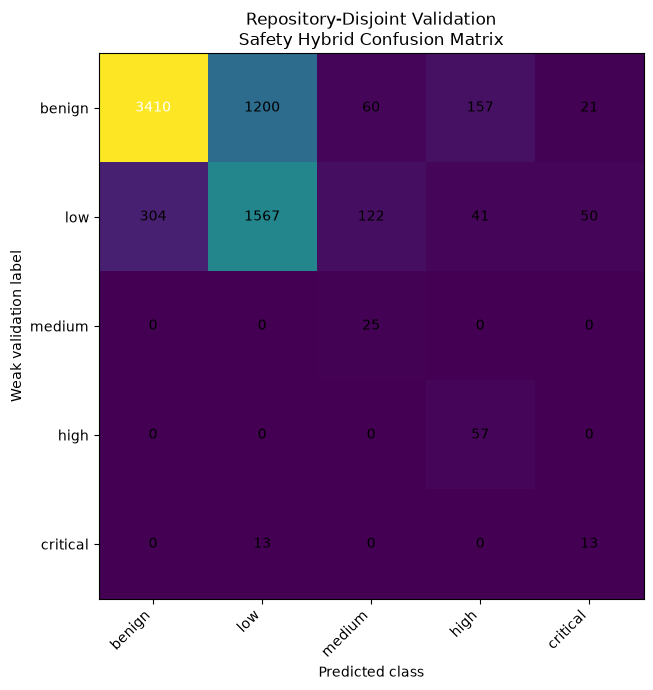

In [46]:
production_confusion_matrix = (
    confusion_matrix(
        true_labels,
        safety_predictions,
        labels=CLASS_ORDER,
    )
)

production_confusion_matrix_df = (
    pd.DataFrame(
        production_confusion_matrix,
        index=[
            f"actual_{class_name}"
            for class_name in CLASS_ORDER
        ],
        columns=[
            f"predicted_{class_name}"
            for class_name in CLASS_ORDER
        ],
    )
)

display(
    production_confusion_matrix_df
)

plt.figure(
    figsize=(9, 7)
)

plt.imshow(
    production_confusion_matrix,
    interpolation="nearest",
)

plt.title(
    "Repository-Disjoint Validation\n"
    "Safety Hybrid Confusion Matrix"
)

plt.xlabel("Predicted class")
plt.ylabel("Weak validation label")

plt.xticks(
    np.arange(
        len(CLASS_ORDER)
    ),
    CLASS_ORDER,
    rotation=45,
    ha="right",
)

plt.yticks(
    np.arange(
        len(CLASS_ORDER)
    ),
    CLASS_ORDER,
)

maximum_value = (
    production_confusion_matrix.max()
    if production_confusion_matrix.size
    else 0
)

threshold = maximum_value / 2

for row_index in range(
    production_confusion_matrix.shape[0]
):
    for column_index in range(
        production_confusion_matrix.shape[1]
    ):
        value = production_confusion_matrix[
            row_index,
            column_index,
        ]

        plt.text(
            column_index,
            row_index,
            str(value),
            ha="center",
            va="center",
            color=(
                "white"
                if value > threshold
                else "black"
            ),
        )

plt.tight_layout()

confusion_figure_path = (
    FIGURES_DIR
    / "safety_hybrid_confusion_matrix.png"
)

plt.savefig(
    confusion_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

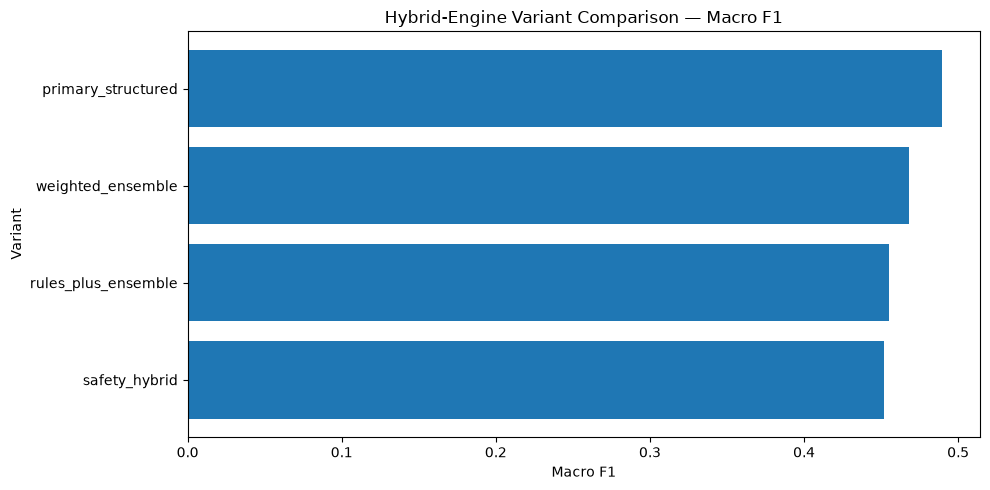

In [47]:
plot_data = (
    variant_results
    .sort_values(
        "macro_f1",
        ascending=True,
    )
)

plt.figure(
    figsize=(10, 5)
)

plt.barh(
    plot_data[
        "variant"
    ],
    plot_data[
        "macro_f1"
    ],
)

plt.title(
    "Hybrid-Engine Variant Comparison — Macro F1"
)

plt.xlabel("Macro F1")
plt.ylabel("Variant")

plt.tight_layout()

variant_figure_path = (
    FIGURES_DIR
    / "hybrid_variant_macro_f1.png"
)

plt.savefig(
    variant_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [48]:
variant_results_path = (
    TABLES_DIR
    / "hybrid_variant_comparison.csv"
)

variant_results.to_csv(
    variant_results_path,
    index=False,
)

per_class_results_path = (
    TABLES_DIR
    / "safety_hybrid_per_class_metrics.csv"
)

production_per_class_metrics.to_csv(
    per_class_results_path,
    index=False,
)

rule_distribution_path = (
    TABLES_DIR
    / "deterministic_rule_distribution.csv"
)

rule_distribution.to_csv(
    rule_distribution_path,
    index=False,
)

rule_override_summary_path = (
    TABLES_DIR
    / "rule_override_summary.csv"
)

rule_override_summary.to_csv(
    rule_override_summary_path,
    index=False,
)

confusion_matrix_path = (
    TABLES_DIR
    / "safety_hybrid_confusion_matrix.csv"
)

production_confusion_matrix_df.to_csv(
    confusion_matrix_path
)

hybrid_predictions_path = (
    PREDICTIONS_DIR
    / "repository_validation_hybrid_predictions.csv.gz"
)

hybrid_data.to_csv(
    hybrid_predictions_path,
    index=False,
    compression="gzip",
)

review_queue_path = (
    REVIEW_DIR
    / "hybrid_manual_review_queue.csv"
)

manual_review_queue.to_csv(
    review_queue_path,
    index=False,
)

critical_false_negative_path = (
    PREDICTIONS_DIR
    / "hybrid_critical_false_negatives.csv.gz"
)

critical_false_negatives.to_csv(
    critical_false_negative_path,
    index=False,
    compression="gzip",
)

print("Variant results :", variant_results_path)
print("Hybrid output   :", hybrid_predictions_path)
print("Review queue    :", review_queue_path)

Variant results : C:\Users\Lenovo\Desktop\DriftGuard\outputs\hybrid_engine\tables\hybrid_variant_comparison.csv
Hybrid output   : C:\Users\Lenovo\Desktop\DriftGuard\outputs\hybrid_engine\predictions\repository_validation_hybrid_predictions.csv.gz
Review queue    : C:\Users\Lenovo\Desktop\DriftGuard\outputs\hybrid_engine\manual_review\hybrid_manual_review_queue.csv


In [49]:
production_result_row = (
    variant_results[
        variant_results[
            "variant"
        ].eq(
            PRODUCTION_VARIANT
        )
    ]
    .iloc[0]
)

hybrid_engine_manifest = {
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "engine_name":
        "DriftGuard Hybrid Risk Engine",

    "production_variant":
        PRODUCTION_VARIANT,

    "primary_learned_model":
        PRIMARY_MODEL_NAME,

    "model_weights":
        MODEL_WEIGHTS,

    "deterministic_rules":
        RULE_DEFINITIONS,

    "consensus_settings": {
        "two_model_high_critical_vote_rank":
            HYBRID_ENGINE_SETTINGS[
                "two_model_high_critical_vote_rank"
            ],

        "single_critical_support_probability":
            HYBRID_ENGINE_SETTINGS[
                "single_critical_support_probability"
            ],
    },

    "validation_metrics": {
        key: (
            None
            if pd.isna(value)
            else float(value)
        )
        for key, value
        in production_result_row.to_dict().items()
        if key not in {
            "variant",
            "production_variant",
        }
    },

    "validation_label_warning": (
        "Repository-disjoint validation uses weak labels. "
        "Deterministic-rule metrics are not independent "
        "human-ground-truth estimates."
    ),

    "selection_policy":
        HYBRID_ENGINE_SETTINGS[
            "selection_policy"
        ],

    "final_test": {
        "status":
            sealed_test_manifest[
                "status"
            ],

        "sha256":
            sealed_test_manifest[
                "sha256"
            ],

        "path":
            sealed_test_manifest[
                "file_path"
            ],
    },

    "next_stage": (
        "Convert hybrid class decisions into cumulative "
        "configuration-drift scores."
    ),
}

hybrid_manifest_path = (
    MANIFESTS_DIR
    / "hybrid_engine_manifest.json"
)

with hybrid_manifest_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        hybrid_engine_manifest,
        file,
        indent=2,
    )

print(
    "Hybrid engine frozen:",
    hybrid_manifest_path,
)

Hybrid engine frozen: C:\Users\Lenovo\Desktop\DriftGuard\outputs\hybrid_engine\manifests\hybrid_engine_manifest.json


In [50]:
rule_input_forbidden_columns = {
    "evaluation_label",
    "weak_label",
    "training_target",
    "primary_rule_id",
    "matched_rule_ids",
    "weak_label_confidence",
    "label_usage",
}

actual_rule_inputs = set(
    RAW_RULE_COLUMNS
)

hybrid_integrity_checks = {
    "Hybrid dataset is not empty":
        len(hybrid_data) > 0,

    "All three learned models are present":
        set(MODEL_NAMES)
        == {
            "structured",
            "transformer",
            "text_baseline",
        },

    "Model weights sum to one":
        np.isclose(
            sum(
                MODEL_WEIGHTS.values()
            ),
            1.0,
        ),

    "No forbidden weak-label columns are rule inputs":
        len(
            actual_rule_inputs
            & rule_input_forbidden_columns
        )
        == 0,

    "All rule severities are valid":
        hybrid_data[
            "rule_severity"
        ].isin(
            CLASS_ORDER
        ).all(),

    "All ensemble predictions are valid":
        hybrid_data[
            "weighted_ensemble_prediction"
        ].isin(
            CLASS_ORDER
        ).all(),

    "All production predictions are valid":
        hybrid_data[
            "safety_hybrid_prediction"
        ].isin(
            CLASS_ORDER
        ).all(),

    "Production prediction count matches input":
        len(
            hybrid_data[
                "safety_hybrid_prediction"
            ]
        )
        == len(
            validation_predictions
        ),

    "Weighted ensemble probabilities sum to one":
        np.allclose(
            weighted_ensemble_probabilities.sum(
                axis=1
            ),
            1.0,
            atol=1e-8,
        ),

    "Safety hybrid probabilities sum to one":
        np.allclose(
            safety_hybrid_probabilities.sum(
                axis=1
            ),
            1.0,
            atol=1e-8,
        ),

    "Rule overrides never lower risk":
        (
            hybrid_data.loc[
                hybrid_data[
                    "rule_override_applied"
                ],
                "safety_hybrid_risk_rank",
            ]
            >= hybrid_data.loc[
                hybrid_data[
                    "rule_override_applied"
                ],
                "rule_severity_rank",
            ]
        ).all(),

    "Production variant exists":
        PRODUCTION_VARIANT
        in set(
            variant_results[
                "variant"
            ]
        ),

    "Final test remains sealed":
        sealed_test_manifest[
            "status"
        ]
        == "SEALED_NOT_LOADED",

    "Hybrid prediction output exists":
        hybrid_predictions_path.exists(),

    "Review queue exists":
        review_queue_path.exists(),

    "Hybrid manifest exists":
        hybrid_manifest_path.exists(),
}

print("Hybrid-engine integrity checks:\n")

for check_name, passed in (
    hybrid_integrity_checks.items()
):
    print(
        f"{'PASSED' if passed else 'FAILED':<8}"
        f" | {check_name}"
    )

failed_hybrid_checks = [
    check_name
    for check_name, passed
    in hybrid_integrity_checks.items()
    if not bool(passed)
]

print(
    "\nFailed integrity checks:",
    len(
        failed_hybrid_checks
    ),
)

Hybrid-engine integrity checks:

PASSED   | Hybrid dataset is not empty
PASSED   | All three learned models are present
PASSED   | Model weights sum to one
PASSED   | No forbidden weak-label columns are rule inputs
PASSED   | All rule severities are valid
PASSED   | All ensemble predictions are valid
PASSED   | All production predictions are valid
PASSED   | Production prediction count matches input
PASSED   | Weighted ensemble probabilities sum to one
PASSED   | Safety hybrid probabilities sum to one
PASSED   | Rule overrides never lower risk
PASSED   | Production variant exists
PASSED   | Final test remains sealed
PASSED   | Hybrid prediction output exists
PASSED   | Review queue exists
PASSED   | Hybrid manifest exists

Failed integrity checks: 0


In [51]:
print("=" * 72)
print("NOTEBOOK 11 — REQUIRED RESULTS")
print("=" * 72)

print("\n1. HYBRID ENGINE CONFIGURATION")
print("-" * 72)

print(
    "Primary learned model :",
    PRIMARY_MODEL_NAME,
)

print(
    "Production variant    :",
    PRODUCTION_VARIANT,
)

print(
    "Model weights         :",
    MODEL_WEIGHTS,
)

print(
    "Deterministic rules   :",
    len(
        RULE_DEFINITIONS
    ),
)

print("\n2. RULE MATCHES")
print("-" * 72)

print(
    "Total validation records:",
    f"{len(hybrid_data):,}",
)

print(
    "Records with rule matches:",
    f"{hybrid_data['rule_match_count'].gt(0).sum():,}",
)

print(
    "Critical rule records:",
    f"{hybrid_data['rule_severity'].eq('critical').sum():,}",
)

print(
    "High rule records:",
    f"{hybrid_data['rule_severity'].eq('high').sum():,}",
)

print(
    "Medium rule records:",
    f"{hybrid_data['rule_severity'].eq('medium').sum():,}",
)

display(
    rule_distribution
)

print("\n3. HYBRID VARIANT COMPARISON")
print("-" * 72)

display(
    variant_results[
        [
            "variant",
            "production_variant",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
            "macro_pr_auc",
            "log_loss",
            "critical_precision",
            "critical_recall",
            "critical_f1",
            "high_critical_precision",
            "high_critical_recall",
            "high_critical_f1",
        ]
    ]
)

print("\n4. PRODUCTION-HYBRID RESULTS")
print("-" * 72)

print(
    "Accuracy                :",
    f"{production_result_row['accuracy']:.4f}",
)

print(
    "Balanced accuracy       :",
    f"{production_result_row['balanced_accuracy']:.4f}",
)

print(
    "Macro F1                :",
    f"{production_result_row['macro_f1']:.4f}",
)

print(
    "Macro PR-AUC            :",
    f"{production_result_row['macro_pr_auc']:.4f}",
)

print(
    "Critical precision      :",
    f"{production_result_row['critical_precision']:.4f}",
)

print(
    "Critical recall         :",
    f"{production_result_row['critical_recall']:.4f}",
)

print(
    "High/critical precision :",
    f"{production_result_row['high_critical_precision']:.4f}",
)

print(
    "High/critical recall    :",
    f"{production_result_row['high_critical_recall']:.4f}",
)

print("\n5. PRODUCTION-HYBRID PER-CLASS RESULTS")
print("-" * 72)

display(
    production_per_class_metrics
)

print("\n6. SAFETY-CRITICAL ERRORS")
print("-" * 72)

print(
    "Critical false negatives     :",
    f"{len(critical_false_negatives):,}",
)

print(
    "High/critical false negatives:",
    f"{len(high_critical_false_negatives):,}",
)

print(
    "High/critical false positives:",
    f"{len(high_critical_false_positives):,}",
)

print("\n7. DECISION INTERVENTIONS")
print("-" * 72)

print(
    "Rule overrides:",
    f"{hybrid_data['rule_override_applied'].sum():,}",
)

print(
    "Model-consensus escalations:",
    f"{hybrid_data['model_consensus_escalation'].sum():,}",
)

print(
    "Three-way model disagreements:",
    f"{hybrid_data['model_three_way_disagreement'].sum():,}",
)

print("\n8. MANUAL REVIEW")
print("-" * 72)

print(
    "Records routed to review:",
    f"{hybrid_data['requires_manual_review'].sum():,}",
)

print(
    "Prioritized review queue:",
    f"{len(manual_review_queue):,}",
)

print(
    "Review queue path:",
    review_queue_path,
)

print("\n9. VALIDATION LIMITATION")
print("-" * 72)

print(
    "These results use repository-disjoint weak labels."
)

print(
    "Rule-enhanced metrics partially measure consistency "
    "with the weak-label rules and are not independent "
    "human-ground-truth estimates."
)

print("\n10. SEALED FINAL TEST")
print("-" * 72)

print(
    "Status:",
    sealed_test_manifest[
        "status"
    ],
)

print(
    "SHA-256:",
    sealed_test_manifest[
        "sha256"
    ],
)

print("\n11. FAILED INTEGRITY CHECKS")
print("-" * 72)

if failed_hybrid_checks:
    for index, check_name in enumerate(
        failed_hybrid_checks,
        start=1,
    ):
        print(
            f"{index}. {check_name}"
        )
else:
    print(
        "No failed integrity checks."
    )

    print(
        "All hybrid-engine integrity checks passed."
    )

print("\n" + "=" * 72)
print("REQUIRED RESULTS GENERATED")
print("=" * 72)

NOTEBOOK 11 — REQUIRED RESULTS

1. HYBRID ENGINE CONFIGURATION
------------------------------------------------------------------------
Primary learned model : structured
Production variant    : safety_hybrid
Model weights         : {'structured': 0.4, 'transformer': 0.35, 'text_baseline': 0.25}
Deterministic rules   : 8

2. RULE MATCHES
------------------------------------------------------------------------
Total validation records: 7,628
Records with rule matches: 252
Critical rule records: 45
High rule records: 48
Medium rule records: 159


,rule_id,records
0,RESOURCE_LIMIT_REMOVED,159
1,INSECURE_PROTOCOL,47
2,AUTH_REMOVED,32
3,TLS_DISABLED,5
4,DEFAULT_CREDENTIALS,5
5,PERMISSIVE_ACCESS_CONTROL,4
6,PUBLIC_SERVICE_BINDING,1



3. HYBRID VARIANT COMPARISON
------------------------------------------------------------------------


,variant,production_variant,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_pr_auc,log_loss,critical_precision,critical_recall,critical_f1,high_critical_precision,high_critical_recall,high_critical_f1
0,primary_structured,False,0.688494,0.523714,0.489688,0.701693,0.514052,4.175535,0.145455,0.307692,0.197531,0.370000,0.445783,0.404372
1,weighted_ensemble,False,0.735085,0.668349,0.467819,0.752485,0.664152,1.518636,0.155556,0.269231,0.197183,0.165414,0.530120,0.252149
2,rules_plus_ensemble,False,0.721307,0.788223,0.455395,0.744125,0.676407,1.626058,0.160494,0.500000,0.242991,0.214953,0.831325,0.341584
3,safety_hybrid,True,0.720455,0.791060,0.451627,0.743860,0.675502,1.625187,0.154762,0.500000,0.236364,0.206490,0.843373,0.331754



4. PRODUCTION-HYBRID RESULTS
------------------------------------------------------------------------
Accuracy                : 0.7205
Balanced accuracy       : 0.7911
Macro F1                : 0.4516
Macro PR-AUC            : 0.6755
Critical precision      : 0.1548
Critical recall         : 0.5000
High/critical precision : 0.2065
High/critical recall    : 0.8434

5. PRODUCTION-HYBRID PER-CLASS RESULTS
------------------------------------------------------------------------


,class,support,precision,recall,f1,average_precision
0,benign,4848,0.918148,0.703383,0.796543,0.923282
1,low,2084,0.563669,0.751919,0.644326,0.781408
2,medium,25,0.120773,1.000000,0.215517,0.899710
3,high,57,0.223529,1.000000,0.365385,0.606588
4,critical,26,0.154762,0.500000,0.236364,0.166523



6. SAFETY-CRITICAL ERRORS
------------------------------------------------------------------------
Critical false negatives     : 13
High/critical false negatives: 13
High/critical false positives: 269

7. DECISION INTERVENTIONS
------------------------------------------------------------------------
Rule overrides: 177
Model-consensus escalations: 29
Three-way model disagreements: 396

8. MANUAL REVIEW
------------------------------------------------------------------------
Records routed to review: 1,145
Prioritized review queue: 750
Review queue path: C:\Users\Lenovo\Desktop\DriftGuard\outputs\hybrid_engine\manual_review\hybrid_manual_review_queue.csv

9. VALIDATION LIMITATION
------------------------------------------------------------------------
These results use repository-disjoint weak labels.
Rule-enhanced metrics partially measure consistency with the weak-label rules and are not independent human-ground-truth estimates.

10. SEALED FINAL TEST
-------------------------------

In [52]:
print("=" * 72)
print("NOTEBOOK 11 COMPLETED")
print("=" * 72)

print(
    "Primary learned model:",
    PRIMARY_MODEL_NAME,
)

print(
    "Production hybrid:",
    PRODUCTION_VARIANT,
)

print(
    "Production macro F1:",
    f"{production_result_row['macro_f1']:.4f}",
)

print(
    "Production critical recall:",
    f"{production_result_row['critical_recall']:.4f}",
)

print(
    "Production high/critical recall:",
    f"{production_result_row['high_critical_recall']:.4f}",
)

print(
    "Critical false negatives:",
    f"{len(critical_false_negatives):,}",
)

print(
    "Rule overrides:",
    f"{hybrid_data['rule_override_applied'].sum():,}",
)

print(
    "Manual-review candidates:",
    f"{hybrid_data['requires_manual_review'].sum():,}",
)

print(
    "Hybrid manifest:",
    hybrid_manifest_path,
)

print(
    "Final test status:",
    sealed_test_manifest[
        "status"
    ],
)

print("\nNext notebook:")
print("12_drift_scoring_engine.ipynb")

NOTEBOOK 11 COMPLETED
Primary learned model: structured
Production hybrid: safety_hybrid
Production macro F1: 0.4516
Production critical recall: 0.5000
Production high/critical recall: 0.8434
Critical false negatives: 13
Rule overrides: 177
Manual-review candidates: 1,145
Hybrid manifest: C:\Users\Lenovo\Desktop\DriftGuard\outputs\hybrid_engine\manifests\hybrid_engine_manifest.json
Final test status: SEALED_NOT_LOADED

Next notebook:
12_drift_scoring_engine.ipynb
